# Project 2: Statistical Sensor Analyser

Load 7 days of real or simulated motor
temperature data. Compute mean, variance, std
dev, percentiles, and z-scores for each sensor
channel. Flag readings with |z| > 2.5 as
statistical anomalies. Plot distribution with
Gaussian overlay and highlight anomalies in
red.

## Skills: scipy.stats, NumPy statistics, z-score anomaly detection

--- Statistical Summary ---
Mean: 65.13°C
Std Dev: 6.73°C
75th Percentile: 67.97°C
Anomalies Detected: 4


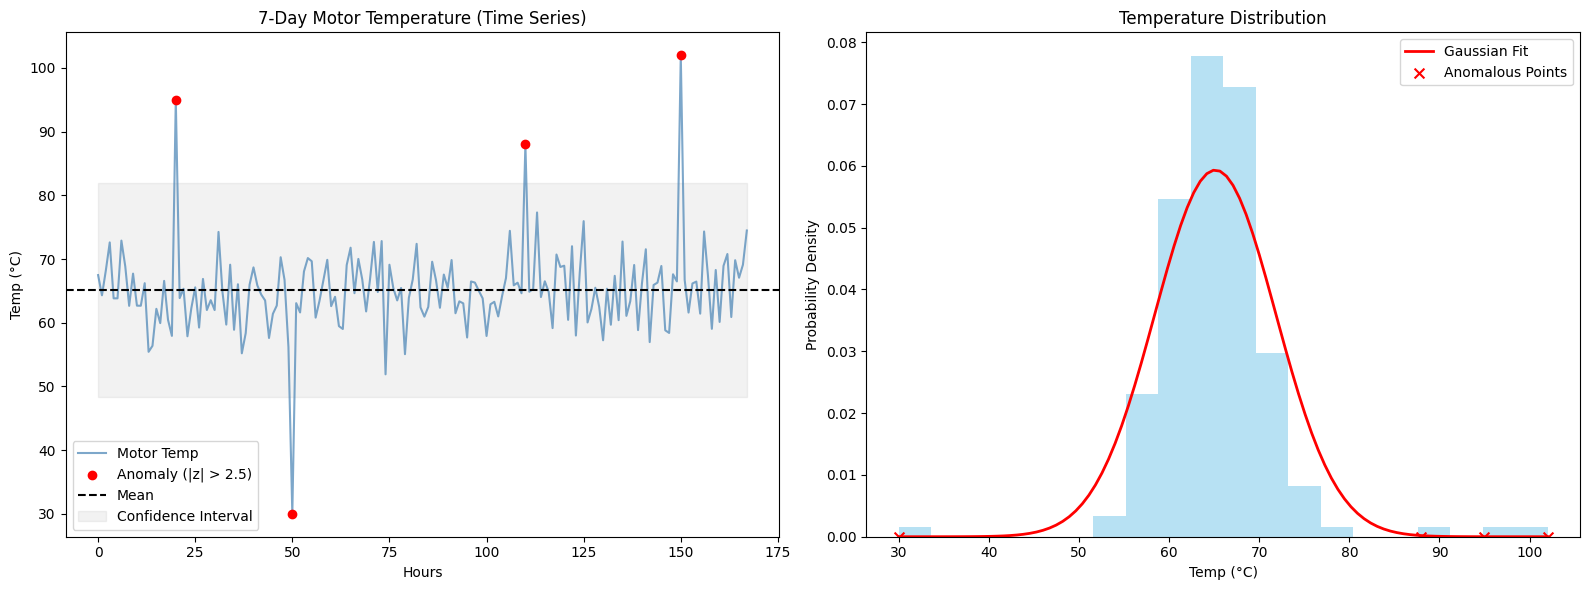

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. SIMULATE DATA ---
# 7 days of motor temperature data (reading every hour = 24 * 7 = 168 readings)
np.random.seed(42)
days = 7
hours = 24
n_readings = days * hours

# Base temp ~ 65°C with some noise
temp_data = np.random.normal(loc=65, scale=5, size=n_readings)

# Inject some intentional anomalies (simulating motor spikes/failures)
anomaly_indices = [20, 50, 110, 150]
temp_data[anomaly_indices] = [95, 30, 88, 102]

# --- 2. STATISTICAL ANALYSIS ---
mean_temp = np.mean(temp_data)
variance_temp = np.var(temp_data)
std_dev = np.std(temp_data)
p25, p75 = np.percentile(temp_data, [25, 75])

# Compute Z-Scores: z = (temp-data - μ) / σ
z_scores = stats.zscore(temp_data)

# Flag anomalies where |z| > 2.5
is_anomaly = np.abs(z_scores) > 2.5
anomalies = temp_data[is_anomaly]
anomaly_time = np.where(is_anomaly)[0]

# Print Report
print(f"--- Statistical Summary ---")
print(f"Mean: {mean_temp:.2f}°C")
print(f"Std Dev: {std_dev:.2f}°C")
print(f"75th Percentile: {p75:.2f}°C")
print(f"Anomalies Detected: {np.sum(is_anomaly)}")

# --- 3. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Time Series (Sensor Journey)
ax1.plot(temp_data, label='Motor Temp', color='steelblue', alpha=0.7)
ax1.scatter(anomaly_time, anomalies, color='red', label='Anomaly (|z| > 2.5)', zorder=5)
ax1.axhline(mean_temp, color='black', linestyle='--', label='Mean')
ax1.fill_between(range(n_readings), mean_temp - 2.5*std_dev, mean_temp + 2.5*std_dev, 
                 color='gray', alpha=0.1, label='Confidence Interval')
ax1.set_title("7-Day Motor Temperature (Time Series)")
ax1.set_xlabel("Hours")
ax1.set_ylabel("Temp (°C)")
ax1.legend()

# Plot B: Distribution with Gaussian Overlay
count, bins, ignored = ax2.hist(temp_data, bins=20, density=True, alpha=0.6, color='skyblue')

# Gaussian Bell Curve Calculation
# Formula: 1/(sigma * sqrt(2 * pi)) * exp( - (x - mu)^2 / (2 * sigma^2) )
x = np.linspace(min(temp_data), max(temp_data), 100)
bell_curve = stats.norm.pdf(x, mean_temp, std_dev)
ax2.plot(x, bell_curve, 'r-', lw=2, label='Gaussian Fit')

# Highlight anomaly region in Histogram
ax2.scatter(anomalies, np.zeros_like(anomalies), color='red', marker='x', s=50, label='Anomalous Points')

ax2.set_title("Temperature Distribution")
ax2.set_xlabel("Temp (°C)")
ax2.set_ylabel("Probability Density")
ax2.legend()

plt.tight_layout()
plt.show()